# 02 — CNN Models for Maxwell Inverse Prediction

This notebook trains convolutional neural networks on three Maxwell-generated datasets:

- `xy`
- `xyr`
- `xyrc`

Each model takes multistatic complex measurement tensors as input and predicts the unknown tumor parameters.

The main goal is to compare inverse-learning performance as the dimension of the unknown parameter vector increases.

In [1]:
# =========================================================
# Imports
# =========================================================
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# allow notebook to import from project root
sys.path.append(os.path.abspath(".."))

from config import load_npz, normalize_targets, denormalize_targets, savefig

In [2]:
# =========================================================
# Device
# =========================================================
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [3]:
# =========================================================
# Load datasets
# =========================================================
data_xy = load_npz("data_xy")
data_xyr = load_npz("data_xyr")
data_xyrc = load_npz("data_xyrc")

X_xy, y_xy = data_xy["X"], data_xy["y"]
X_xyr, y_xyr = data_xyr["X"], data_xyr["y"]
X_xyrc, y_xyrc = data_xyrc["X"], data_xyrc["y"]

print("XY   :", X_xy.shape, y_xy.shape)
print("XYR  :", X_xyr.shape, y_xyr.shape)
print("XYRC :", X_xyrc.shape, y_xyrc.shape)

XY   : (300, 16, 16, 2) (300, 2)
XYR  : (400, 16, 16, 2) (400, 3)
XYRC : (500, 16, 16, 2) (500, 4)


In [4]:
# =========================================================
# Train/val/test split helper
# =========================================================
def split_dataset(X, y, train_frac=0.7, val_frac=0.15, seed=123):
    rng = np.random.default_rng(seed)
    n = len(X)
    idx = rng.permutation(n)

    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    idx_train = idx[:n_train]
    idx_val = idx[n_train:n_train + n_val]
    idx_test = idx[n_train + n_val:]

    return (
        X[idx_train], y[idx_train],
        X[idx_val], y[idx_val],
        X[idx_test], y[idx_test]
    )

In [5]:
# =========================================================
# Tensor preparation helper
# Converts (N, H, W, C) -> (N, C, H, W)
# =========================================================
def prepare_tensors(X, y):
    X_t = torch.tensor(np.transpose(X, (0, 3, 1, 2)), dtype=torch.float32)
    y_t = torch.tensor(normalize_targets(y), dtype=torch.float32)
    return X_t, y_t

In [25]:
# =========================================================
# Compact CNN regressor
# =========================================================
class InverseCNN(nn.Module):
    def __init__(self, out_dim):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2))
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 2 * 2, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [26]:
# =========================================================
# Training helper
# =========================================================
def train_model(X, y, out_dim, epochs=80, batch_size=16, lr=1e-3, seed=123, loss_weights=None):
    X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X, y, seed=seed)

    X_train_t, y_train_t = prepare_tensors(X_train, y_train)
    X_val_t, y_val_t = prepare_tensors(X_val, y_val)
    X_test_t, y_test_t = prepare_tensors(X_test, y_test)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

    model = InverseCNN(out_dim=out_dim).to(device)

    if loss_weights is None:
        criterion = nn.MSELoss()
    else:
        criterion = WeightedMSELoss(loss_weights).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = np.inf
    best_state = None

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * xb.size(0)

        val_loss /= len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | train={train_loss:.6f} | val={val_loss:.6f}")

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        y_pred_test = model(X_test_t.to(device)).cpu().numpy()

    y_pred_test = denormalize_targets(y_pred_test)
    y_test_true = y_test.copy()

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "X_test": X_test,
        "y_test": y_test_true,
        "y_pred": y_pred_test,
    }

## Train CNN for `xy`

Predict tumor center `(x, y)` from Maxwell measurement tensors.

In [28]:
# =========================================================
# Compare CNN vs MLP on XY
# =========================================================

results_xy = train_model(
    X_xy, y_xy,
    out_dim=2,
    epochs=80,
    seed=101
)


Epoch   1/80 | train=0.337322 | val=0.339020
Epoch  10/80 | train=0.139094 | val=0.114542
Epoch  20/80 | train=0.039475 | val=0.034725
Epoch  30/80 | train=0.017926 | val=0.012317
Epoch  40/80 | train=0.011405 | val=0.010200
Epoch  50/80 | train=0.010305 | val=0.008153
Epoch  60/80 | train=0.009364 | val=0.009026
Epoch  70/80 | train=0.009272 | val=0.008665
Epoch  80/80 | train=0.008476 | val=0.008608


## Train CNN for `xyr`

Predict tumor center and radius `(x, y, r)` from Maxwell measurement tensors.

In [11]:
# =========================================================
# Train XYR model
# =========================================================
results_xyr = train_model(
    X_xyr, y_xyr,
    out_dim=3,
    epochs=80,
    batch_size=16,
    lr=1e-3,
    seed=102
)

Epoch   1/80 | train=0.296497 | val=0.248625
Epoch  10/80 | train=0.053217 | val=0.066096
Epoch  20/80 | train=0.028828 | val=0.041428
Epoch  30/80 | train=0.022649 | val=0.047000
Epoch  40/80 | train=0.021389 | val=0.046208
Epoch  50/80 | train=0.020234 | val=0.052761
Epoch  60/80 | train=0.020255 | val=0.050443
Epoch  70/80 | train=0.019204 | val=0.052410
Epoch  80/80 | train=0.018577 | val=0.053575


## Train CNN for `xyrc`

Predict tumor center, radius, and contrast `(x, y, r, c)` from Maxwell measurement tensors.

In [12]:
# =========================================================
# Train XYRC model
# =========================================================
results_xyrc = train_model(
    X_xyrc, y_xyrc,
    out_dim=4,
    epochs=80,
    batch_size=16,
    lr=1e-3,
    seed=103
)

Epoch   1/80 | train=0.267404 | val=0.209241
Epoch  10/80 | train=0.049887 | val=0.056568
Epoch  20/80 | train=0.030815 | val=0.034365
Epoch  30/80 | train=0.027424 | val=0.028327
Epoch  40/80 | train=0.026265 | val=0.026673
Epoch  50/80 | train=0.025607 | val=0.026692
Epoch  60/80 | train=0.024142 | val=0.024790
Epoch  70/80 | train=0.024426 | val=0.024654
Epoch  80/80 | train=0.022527 | val=0.025548


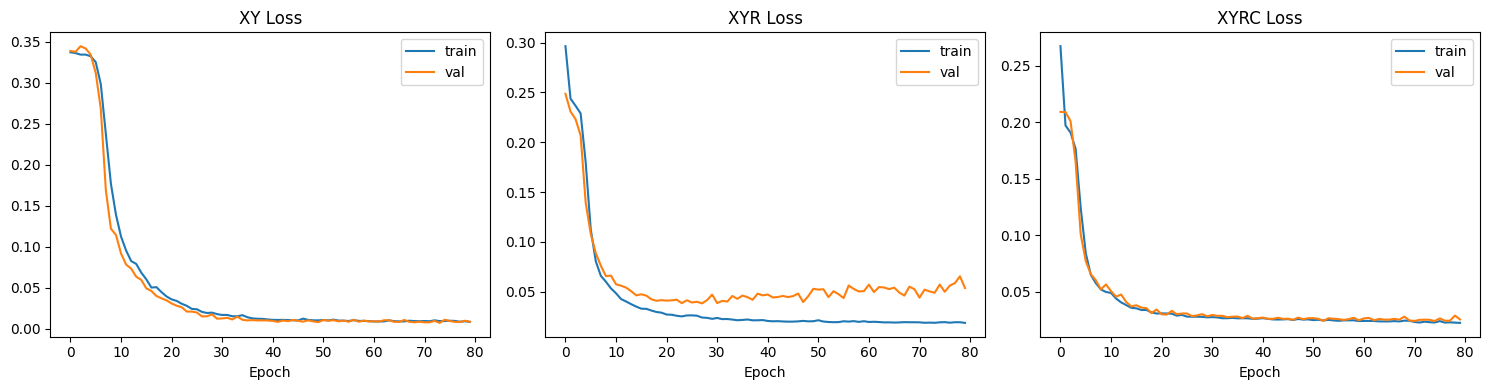

In [29]:
# =========================================================
# Plot training curves
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_xy["train_losses"], label="train")
axes[0].plot(results_xy["val_losses"], label="val")
axes[0].set_title("XY Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(results_xyr["train_losses"], label="train")
axes[1].plot(results_xyr["val_losses"], label="val")
axes[1].set_title("XYR Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(results_xyrc["train_losses"], label="train")
axes[2].plot(results_xyrc["val_losses"], label="val")
axes[2].set_title("XYRC Loss")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
# =========================================================
# Compute test errors (denormalized)
# =========================================================
def compute_errors(results, name):
    y_true = results["y_test"]
    y_pred = results["y_pred"]

    err = np.abs(y_pred - y_true)

    print(f"\n{name} errors:")
    print("Mean absolute error:", err.mean(axis=0))
    print("Std:", err.std(axis=0))

    return err

err_xy = compute_errors(results_xy, "XY")
err_xyr = compute_errors(results_xyr, "XYR")
err_xyrc = compute_errors(results_xyrc, "XYRC")


XY errors:
Mean absolute error: [0.00266456 0.00272081]
Std: [0.00423912 0.00404968]

XYR errors:
Mean absolute error: [0.00757273 0.00639816 0.00323997]
Std: [0.00610859 0.00552664 0.0020442 ]

XYRC errors:
Mean absolute error: [6.5834355e-03 6.1644409e-03 3.3201056e-03 1.1705315e+01]
Std: [5.6810300e-03 5.1680058e-03 2.0895102e-03 6.5886579e+00]


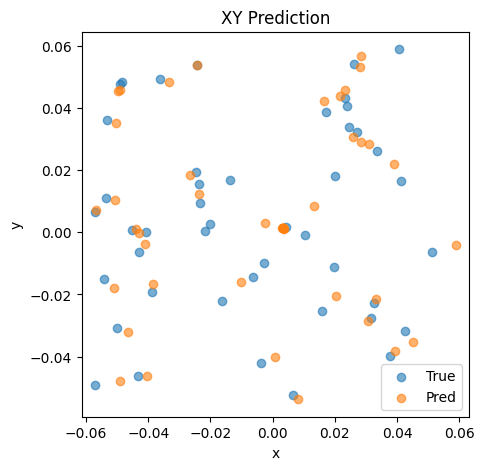

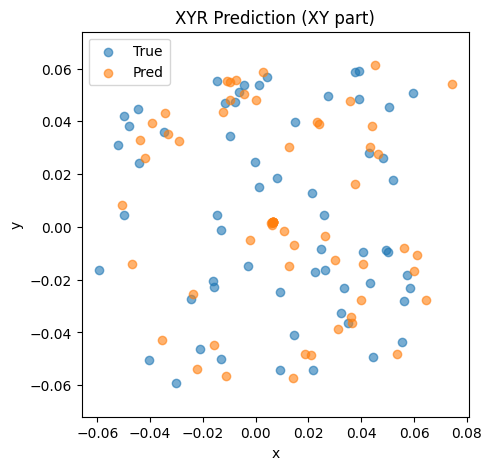

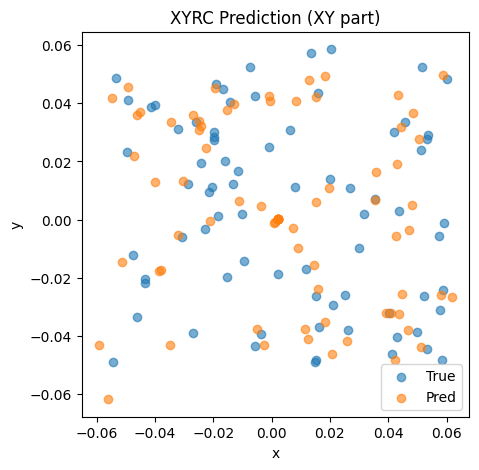

In [30]:
# =========================================================
# XY scatter (true vs predicted)
# =========================================================
def plot_xy(results, title):
    y_true = results["y_test"]
    y_pred = results["y_pred"]

    plt.figure(figsize=(5,5))
    plt.scatter(y_true[:,0], y_true[:,1], label="True", alpha=0.6)
    plt.scatter(y_pred[:,0], y_pred[:,1], label="Pred", alpha=0.6)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

plot_xy(results_xy, "XY Prediction")
plot_xy(results_xyr, "XYR Prediction (XY part)")
plot_xy(results_xyrc, "XYRC Prediction (XY part)")

In [31]:
# =========================================================
# Physical RMSE / MAE by variable
# =========================================================
def summarize_results(results, name):
    y_true = results["y_test"]
    y_pred = results["y_pred"]

    err = y_pred - y_true
    mae = np.mean(np.abs(err), axis=0)
    rmse = np.sqrt(np.mean(err**2, axis=0))

    print(f"\n{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)

summarize_results(results_xy, "XY")
summarize_results(results_xyr, "XYR")
summarize_results(results_xyrc, "XYRC")


XY
MAE : [0.00492046 0.0034398 ]
RMSE: [0.00793552 0.00510099]

XYR
MAE : [0.00757273 0.00639816 0.00323997]
RMSE: [0.0097294  0.0084546  0.00383095]

XYRC
MAE : [6.5834355e-03 6.1644409e-03 3.3201056e-03 1.1705315e+01]
RMSE: [8.6957291e-03 8.0441656e-03 3.9229016e-03 1.3432232e+01]


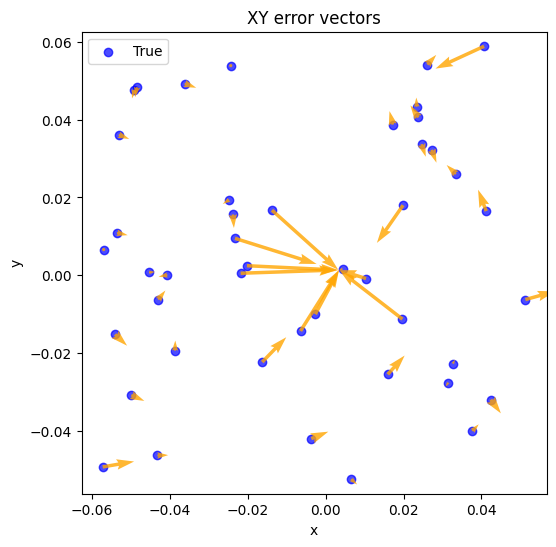

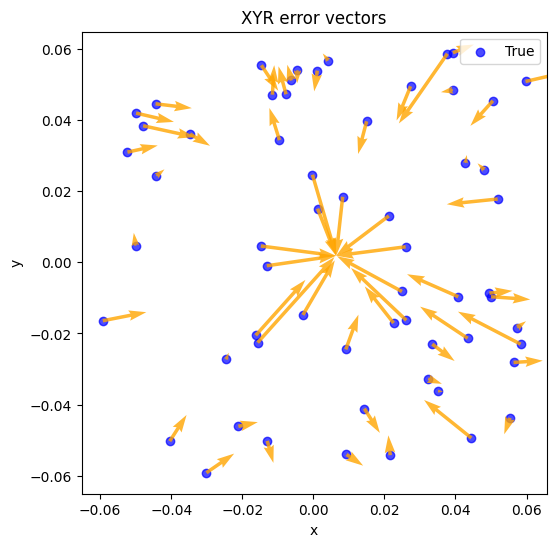

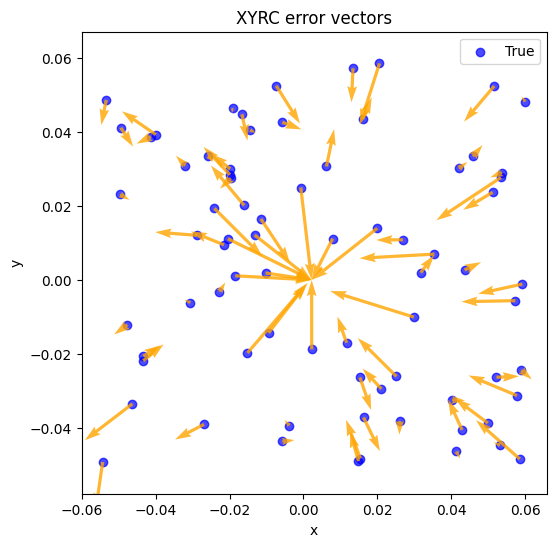

In [32]:
# =========================================================
# XY error vectors
# =========================================================
def plot_xy_quiver(results, title):
    y_true = results["y_test"]
    y_pred = results["y_pred"]

    dx = y_pred[:, 0] - y_true[:, 0]
    dy = y_pred[:, 1] - y_true[:, 1]

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true[:, 0], y_true[:, 1], c="blue", label="True", alpha=0.7)
    plt.quiver(
        y_true[:, 0], y_true[:, 1],
        dx, dy,
        angles='xy', scale_units='xy', scale=1,
        color='orange', alpha=0.8
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()

plot_xy_quiver(results_xy, "XY error vectors")
plot_xy_quiver(results_xyr, "XYR error vectors")
plot_xy_quiver(results_xyrc, "XYRC error vectors")

In [21]:
# =========================================================
# Tiny-set overfit helper: train = evaluate on same data
# =========================================================
def train_model_overfit(X, y, out_dim, epochs=300, batch_size=10, lr=1e-3):
    X_t, y_t = prepare_tensors(X, y)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    model = InverseCNN(out_dim=out_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        model.train()
        running = 0.0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            running += loss.item() * xb.size(0)

        epoch_loss = running / len(loader.dataset)
        losses.append(epoch_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | loss={epoch_loss:.6f}")

    model.eval()
    with torch.no_grad():
        y_pred = model(X_t.to(device)).cpu().numpy()

    y_pred = denormalize_targets(y_pred)

    return {
        "model": model,
        "losses": losses,
        "y_test": y.copy(),
        "y_pred": y_pred,
    }

## Pairwise measurement distance vs location distance

To probe whether the inverse map is locally well-separated, we compare:

- distance between true tumor locations in physical space
- distance between their Maxwell measurement tensors

If the inverse problem is well-conditioned, samples that are far apart in location should also tend to be far apart in measurement space.

If very different locations produce very similar measurements, that is evidence of ambiguity in the forward map.

In [33]:
# =========================================================
# Pairwise location-distance vs measurement-distance
# Using XY dataset only
# =========================================================
from itertools import combinations

# flatten measurements
X_flat = X_xy.reshape(len(X_xy), -1)
xy_true = y_xy

loc_dists = []
meas_dists = []

for i, j in combinations(range(len(X_xy)), 2):
    d_loc = np.linalg.norm(xy_true[i] - xy_true[j])
    d_meas = np.linalg.norm(X_flat[i] - X_flat[j])

    loc_dists.append(d_loc)
    meas_dists.append(d_meas)

loc_dists = np.array(loc_dists)
meas_dists = np.array(meas_dists)

print("Number of pairs:", len(loc_dists))
print("Correlation between location distance and measurement distance:",
      np.corrcoef(loc_dists, meas_dists)[0, 1])

Number of pairs: 44850
Correlation between location distance and measurement distance: 0.4326575708002395


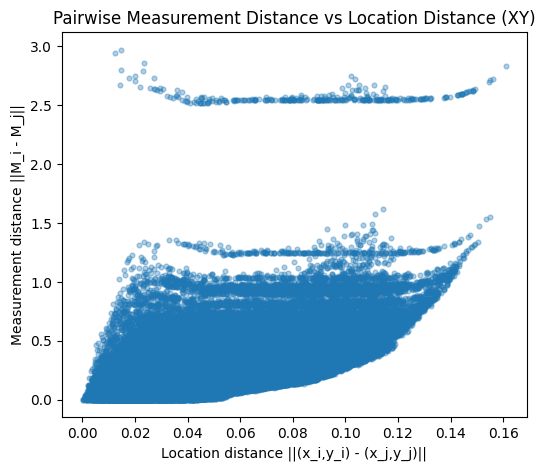

Potentially ambiguous pair count: 66


In [34]:
# =========================================================
# Plot pairwise relationship
# =========================================================
plt.figure(figsize=(6, 5))
plt.scatter(loc_dists, meas_dists, alpha=0.35, s=12)

plt.xlabel("Location distance ||(x_i,y_i) - (x_j,y_j)||")
plt.ylabel("Measurement distance ||M_i - M_j||")
plt.title("Pairwise Measurement Distance vs Location Distance (XY)")
plt.show()

# optional: show potentially ambiguous pairs
threshold_loc = np.percentile(loc_dists, 75)   # far apart in location
threshold_meas = np.percentile(meas_dists, 25) # close in measurement

ambiguous_idx = np.where((loc_dists > threshold_loc) & (meas_dists < threshold_meas))[0]
print("Potentially ambiguous pair count:", len(ambiguous_idx))

## Local sensitivity of the Maxwell forward map

To test whether the `xy` inverse problem is locally well-conditioned, we examine how the measurement tensor changes under small perturbations in `x` and `y`.

For a fixed tumor radius and contrast, we estimate:

- sensitivity to small shifts in `x`
- sensitivity to small shifts in `y`

If these sensitivities are weak or too similar, then the inverse map can be locally ambiguous even in the `xy` case.

In [35]:
# =========================================================
# Local finite-difference sensitivity for M(x,y)
# =========================================================
from src.maxwell import simulate_multistatic_measurement

def flatten_measurement(M):
    return M.reshape(-1)

def local_jacobian_xy(x0, y0, r0=0.01, c0=50.0, sigma0=4.0, h=0.003):
    M_xp = flatten_measurement(simulate_multistatic_measurement(x0 + h, y0, r0, c0, sigma0))
    M_xm = flatten_measurement(simulate_multistatic_measurement(x0 - h, y0, r0, c0, sigma0))
    M_yp = flatten_measurement(simulate_multistatic_measurement(x0, y0 + h, r0, c0, sigma0))
    M_ym = flatten_measurement(simulate_multistatic_measurement(x0, y0 - h, r0, c0, sigma0))

    dM_dx = (M_xp - M_xm) / (2 * h)
    dM_dy = (M_yp - M_ym) / (2 * h)

    # convert complex derivatives to real-valued stacked vectors
    vx = np.concatenate([np.real(dM_dx), np.imag(dM_dx)])
    vy = np.concatenate([np.real(dM_dy), np.imag(dM_dy)])

    J = np.stack([vx, vy], axis=1)   # shape (2*num_features, 2)

    svals = np.linalg.svd(J, compute_uv=False)
    cond = svals[0] / (svals[1] + 1e-12)

    return {
        "J": J,
        "svals": svals,
        "cond": cond,
        "norm_dx": np.linalg.norm(vx),
        "norm_dy": np.linalg.norm(vy),
        "cos_angle": np.dot(vx, vy) / ((np.linalg.norm(vx) * np.linalg.norm(vy)) + 1e-12)
    }

# choose a few representative points
test_points = [
    (-0.04, -0.04),
    (-0.02,  0.00),
    ( 0.00,  0.00),
    ( 0.03,  0.02),
    ( 0.05, -0.03),
]

results_local = []
for (x0, y0) in test_points:
    out = local_jacobian_xy(x0, y0)
    results_local.append((x0, y0, out))

for x0, y0, out in results_local:
    print(f"\nPoint ({x0:.3f}, {y0:.3f})")
    print("  ||dM/dx||   =", out["norm_dx"])
    print("  ||dM/dy||   =", out["norm_dy"])
    print("  singular vals =", out["svals"])
    print("  condition no. =", out["cond"])
    print("  cos(angle)    =", out["cos_angle"])


Point (-0.040, -0.040)
  ||dM/dx||   = 29.034824267721298
  ||dM/dy||   = 28.90947234701107
  singular vals = [35.7981826 19.9316014]
  condition no. = 1.796051500333453
  cos(angle)    = 0.5267041052618542

Point (-0.020, 0.000)
  ||dM/dx||   = 0.10062829957242499
  ||dM/dy||   = 0.01328709264401349
  singular vals = [0.100636   0.01322866]
  condition no. = 7.60742116830055
  cos(angle)    = -0.09286661314232252

Point (0.000, 0.000)
  ||dM/dx||   = 1.4520578965446734e-13
  ||dM/dy||   = 1.4520578965446734e-13
  singular vals = [1.46033607e-13 1.44373226e-13]
  condition no. = 0.12761012179169312
  cos(angle)    = 2.41092951351621e-16

Point (0.030, 0.020)
  ||dM/dx||   = 11.500621351152372
  ||dM/dy||   = 8.291363703297408
  singular vals = [12.73930565  6.22262767]
  condition no. = 2.047255004116005
  cos(angle)    = 0.555782414460552

Point (0.050, -0.030)
  ||dM/dx||   = 30.919921292127277
  ||dM/dy||   = 29.721120510526706
  singular vals = [38.33121802 19.23809403]
  conditio

## Sensitivity cross-sections through the domain center

To test whether the Maxwell forward map becomes locally flat near the center, we compute finite-difference sensitivities along two cross-sections:

- horizontal line: `y = 0`, varying `x`
- vertical line: `x = 0`, varying `y`

If the sensitivity norms and smallest singular value collapse near the center, that would explain why inverse predictions are biased inward even in the `xy` case.

In [37]:
# =========================================================
# Cross-section sensitivity scans
# =========================================================
x_line = np.linspace(-0.055, 0.055, 11)
y_line = np.linspace(-0.055, 0.055, 11)

scan_x = []
for x0 in x_line:
    out = local_jacobian_xy(x0, 0.0, r0=0.01, c0=50.0, sigma0=4.0, h=0.003)
    scan_x.append({
        "coord": x0,
        "norm_dx": out["norm_dx"],
        "norm_dy": out["norm_dy"],
        "smin": out["svals"][1],
        "smax": out["svals"][0],
    })

scan_y = []
for y0 in y_line:
    out = local_jacobian_xy(0.0, y0, r0=0.01, c0=50.0, sigma0=4.0, h=0.003)
    scan_y.append({
        "coord": y0,
        "norm_dx": out["norm_dx"],
        "norm_dy": out["norm_dy"],
        "smin": out["svals"][1],
        "smax": out["svals"][0],
    })

x_coords = np.array([d["coord"] for d in scan_x])
x_norm_dx = np.array([d["norm_dx"] for d in scan_x])
x_norm_dy = np.array([d["norm_dy"] for d in scan_x])
x_smin    = np.array([d["smin"] for d in scan_x])

y_coords = np.array([d["coord"] for d in scan_y])
y_norm_dx = np.array([d["norm_dx"] for d in scan_y])
y_norm_dy = np.array([d["norm_dy"] for d in scan_y])
y_smin    = np.array([d["smin"] for d in scan_y])

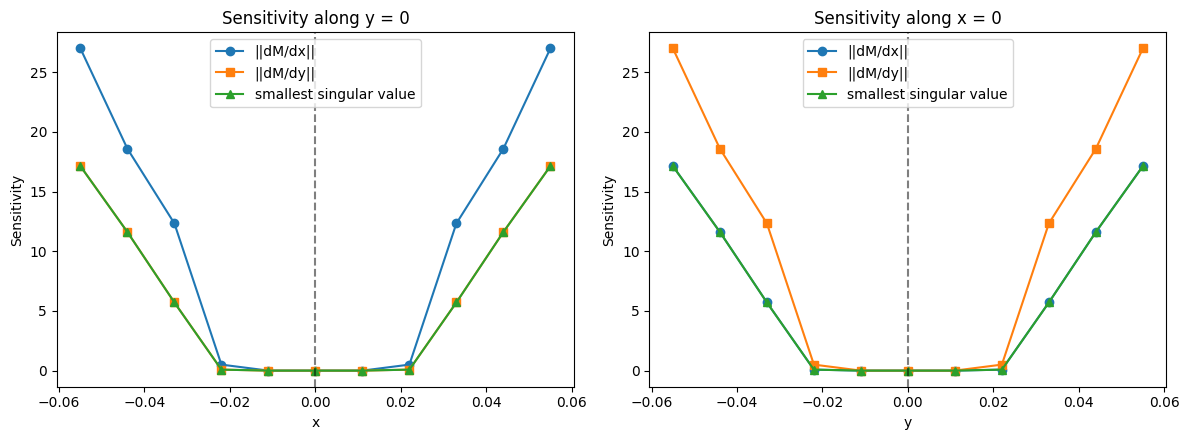

Center values:
Along y=0 at x≈0
  ||dM/dx|| = 1.4520578965446734e-13
  ||dM/dy|| = 1.4520578965446734e-13
  s_min     = 1.443732260421779e-13

Along x=0 at y≈0
  ||dM/dx|| = 1.4520578965446734e-13
  ||dM/dy|| = 1.4520578965446734e-13
  s_min     = 1.443732260421779e-13


In [38]:
# =========================================================
# Plot cross-section sensitivities
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# horizontal line: y = 0
axes[0].plot(x_coords, x_norm_dx, 'o-', label='||dM/dx||')
axes[0].plot(x_coords, x_norm_dy, 's-', label='||dM/dy||')
axes[0].plot(x_coords, x_smin, '^-', label='smallest singular value')
axes[0].axvline(0.0, color='k', linestyle='--', alpha=0.5)
axes[0].set_title("Sensitivity along y = 0")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Sensitivity")
axes[0].legend()

# vertical line: x = 0
axes[1].plot(y_coords, y_norm_dx, 'o-', label='||dM/dx||')
axes[1].plot(y_coords, y_norm_dy, 's-', label='||dM/dy||')
axes[1].plot(y_coords, y_smin, '^-', label='smallest singular value')
axes[1].axvline(0.0, color='k', linestyle='--', alpha=0.5)
axes[1].set_title("Sensitivity along x = 0")
axes[1].set_xlabel("y")
axes[1].set_ylabel("Sensitivity")
axes[1].legend()

plt.tight_layout()
plt.show()

# center values
ix0 = np.argmin(np.abs(x_coords))
iy0 = np.argmin(np.abs(y_coords))

print("Center values:")
print("Along y=0 at x≈0")
print("  ||dM/dx|| =", x_norm_dx[ix0])
print("  ||dM/dy|| =", x_norm_dy[ix0])
print("  s_min     =", x_smin[ix0])

print("\nAlong x=0 at y≈0")
print("  ||dM/dx|| =", y_norm_dx[iy0])
print("  ||dM/dy|| =", y_norm_dy[iy0])
print("  s_min     =", y_smin[iy0])